# Graph embeddings

Environment set up:
* uses mazedyn conda env
* karateclub works but pydot/plotting does not

### Imports

In [2]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy
import os
import pandas as pd
import pydot
import random
import warnings

from reeb_utils import do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

### Load data

In [3]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

# test_df.head()

### Compute treebs

In [4]:
# JK let's make ten of them!

# get all test paths by quartile
# graphs = {}
# for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
#     for i in range(1,5):
#         graphs[(start_node, end_node, i)] = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)

# # extract features for each graph
# features = np.array([extract_tree_features(graphs[g], g[0]+"_0") for g in graphs])
# # get quartiles for each path
# qs = [graph[2] for graph in graphs]



treebs = []
qs = []
# count = 0
for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
    for i in range(1,5):
        G = do_reeb_for_start_end(test_df, start_node, end_node, i, use_turns=False)
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
        treebs.append(new_G)
        qs.append(i)
    # count += 1
    # if count == 10: break

### Do graph embeddings

https://karateclub.readthedocs.io/en/latest/modules/root.html#whole-graph-embedding

#### Options:
* **WaveletCharacteristic:** An implementation of “WaveCharacteristic” from the CIKM ‘21 paper “Graph Embedding via Diffusion-Wavelets-Based Node Feature Distribution Characterization”. The procedure uses characteristic functions of node features with wavelet function weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.
* **FeatherGraph:** An implementation of “FEATHER-G” from the CIKM ‘20 paper “Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models”. The procedure uses characteristic functions of node features with random walk weights to describe node neighborhoods. These node level features are pooled by mean pooling to create graph level statistics.
* **Graph2Vec:** An implementation of “Graph2Vec” from the MLGWorkshop ‘17 paper “Graph2Vec: Learning Distributed Representations of Graphs”. The procedure creates Weisfeiler-Lehman tree features for nodes in graphs. Using these features a document (graph) - feature co-occurrence matrix is decomposed in order to generate representations for the graphs.
* **IGE:** An implementation of “Invariant Graph Embedding” from the ICML 2019 Workshop on Learning and Reasoning with Graph-Structured Data paper “Invariant Embedding for Graph Classification”. The procedure computes a mixture of spectral and node embedding based features. Specifically, it uses scattering, eigenvalues and pooled node feature embeddings to create graph descriptors.

In [5]:
# model = kc.WaveletCharacteristic()
# model = kc.FeatherGraph()
model = kc.Graph2Vec()
# model = kc.IGE()
model.fit(treebs)

X = model.get_embedding()
print(X.shape)

(288, 128)


### Cluster graph embeddings

In [6]:
num_clusters = 4

kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(X)

labels = kmeans.labels_

### Evaluate clustering

In [18]:
true_labels = [q-1 for q in qs]
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")

ARI: 0.26 (random would be: -0.01)
NMI: 0.31 (random would be: 0.00)


### Visualise clustering

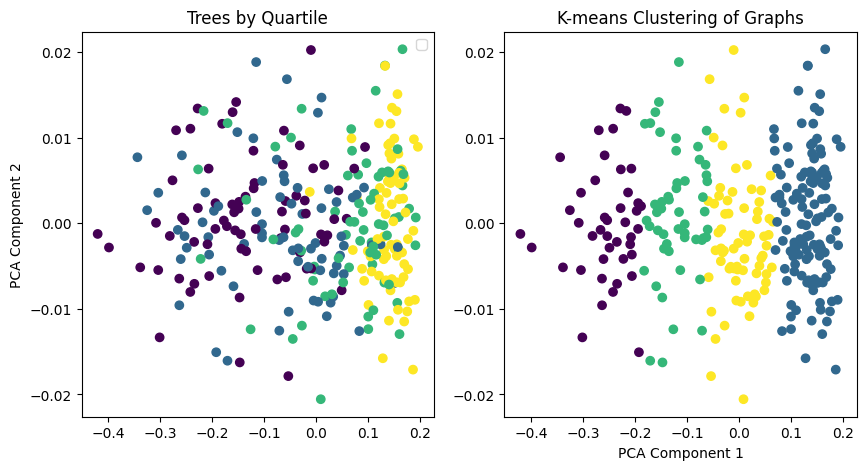

In [7]:
# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(X)

# Plot the clusters
fix, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(reduced_features[:, 0], reduced_features[:, 1], c=qs, cmap='viridis')
axs[0].set_title('Trees by Quartile')
axs[1].scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='viridis')
axs[1].set_title('K-means Clustering of Graphs')
plt.xlabel('PCA Component 1')
axs[0].set_ylabel('PCA Component 2')
axs[0].legend()
plt.show()

#### Tree plotting does not work

In [9]:
## NOTE GRAPHING DOES NOT WORK IN THIS ENV

# def plot_treeb(G):
#     fig = plt.figure(figsize=(20,10))
#     this_ax = plt.gca()

#     pos = graphviz_layout(G)#, prog="dot")
    
#     edges = G.edges()
#     # colors = [G[u][v]['color'] for u,v in edges]
#     weights = [G[u][v]['weight'] * .8 for u,v in edges]

#     nodes = G.nodes()
#     # for n in nodes:
#     #     print(n, G.nodes[n])
#     n_labels = {n: n[:-2] for n in G}
#     n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
#     # print(n_colors)
#     # print ((q-1) // 2, (q-1) % 2)
#     nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=1000, alpha=0.7, ax=this_ax)
#     nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
#     nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=26, font_weight="bold", ax=this_ax)

#     this_ax.axis("off")
    
# G = do_reeb_for_start_end(test_df, "A", "W", 1, use_turns=True)
# plot_treeb(G)